CNN 학습 결과가 잘 나오는 MNIST 데이터셋으로 실습을 진행해봅시다!

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import cv2
import matplotlib.pyplot as plt

In [23]:
# myCNN 클래스 정의
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size = 5, padding = 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 5, padding = 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 5, padding = 2)
        self.fc1 = nn.Linear(128*3*3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.relu(F.max_pool2d(self.conv3(x), 2))
        x = x.view(-1, 128*3*3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim = 1)

In [24]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST('./data', train = False, transform = transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 1000, shuffle = False)

모델, 손실 함수, 최적화 알고리즘 설정 ✅

In [25]:
# TODO
# 디바이스 설정 (CUDA가 가능하면 GPU 사용)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 생성 및 GPU로 이동
model = myCNN().to(device)

# 손실 함수 및 최적화 알고리즘 설정
criterion = nn.CrossEntropyLoss()  # 다중 클래스 분류 문제이므로 CrossEntropyLoss 사용
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 최적화 사용

모델 학습 ✅

In [26]:
# TODO
# 학습 과정 (Train)
# 단일 Epoch 학습 (1회 학습)
model.train()  # 모델을 학습 모드로 설정
train_losses = []  # 학습 손실 저장 리스트

running_loss = 0.0

for batch_idx, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)

    optimizer.zero_grad()  # 기울기 초기화
    output = model(data)  # 예측값 계산
    loss = criterion(output, target)  # 손실 계산
    loss.backward()  # 역전파
    optimizer.step()  # 가중치 업데이트

    running_loss += loss.item()

    if batch_idx % 100 == 0:
        print(f'Step {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}')

# 평균 학습 손실 저장
avg_train_loss = running_loss / len(train_loader)
train_losses.append(avg_train_loss)


Step 0/938, Loss: 2.3074
Step 100/938, Loss: 0.0638
Step 200/938, Loss: 0.0241
Step 300/938, Loss: 0.0361
Step 400/938, Loss: 0.0636
Step 500/938, Loss: 0.0061
Step 600/938, Loss: 0.0467
Step 700/938, Loss: 0.1166
Step 800/938, Loss: 0.0742
Step 900/938, Loss: 0.0901


모델 평가 ✅

In [27]:
# TODO
# 평가 과정 (Evaluation)
model.eval()  # 평가 모드 설정
test_losses = []
test_accuracies = []

with torch.no_grad():
    test_loss = 0.0
    correct = 0
    total = 0

    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = criterion(output, target)
        test_loss += loss.item()

        pred = output.argmax(dim=1, keepdim=True)  # 가장 높은 확률을 가진 클래스를 예측값으로 설정
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)
    
    # 평균 테스트 손실 및 정확도 계산
    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    accuracy = 100.0 * correct / total
    test_accuracies.append(accuracy)

print(f'Test Loss: {avg_test_loss:.4f}, Test Accuracy: {accuracy:.2f}%')


Test Loss: 0.0418, Test Accuracy: 98.73%


10회 반복 시행 ✅

In [28]:
# TODO
# 모델 학습 및 평가 10회 반복
train_losses = []
test_losses = []
test_accuracies = []

num_epochs = 10  # 10번 반복

for epoch in range(num_epochs):
    print(f"\n=== Epoch {epoch+1}/{num_epochs} ===")

    # 학습
    model.train()
    running_loss = 0.0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # 평가
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            test_loss += loss.item()

            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)

    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    accuracy = 100.0 * correct / total
    test_accuracies.append(accuracy)

    print(f'Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, Test Accuracy: {accuracy:.2f}%')



=== Epoch 1/10 ===
Train Loss: 0.0389, Test Loss: 0.0308, Test Accuracy: 99.08%

=== Epoch 2/10 ===
Train Loss: 0.0267, Test Loss: 0.0307, Test Accuracy: 99.04%

=== Epoch 3/10 ===
Train Loss: 0.0207, Test Loss: 0.0289, Test Accuracy: 99.15%

=== Epoch 4/10 ===
Train Loss: 0.0173, Test Loss: 0.0261, Test Accuracy: 99.07%

=== Epoch 5/10 ===
Train Loss: 0.0133, Test Loss: 0.0358, Test Accuracy: 99.03%

=== Epoch 6/10 ===
Train Loss: 0.0112, Test Loss: 0.0338, Test Accuracy: 99.20%

=== Epoch 7/10 ===
Train Loss: 0.0113, Test Loss: 0.0540, Test Accuracy: 98.61%

=== Epoch 8/10 ===
Train Loss: 0.0099, Test Loss: 0.0341, Test Accuracy: 99.15%

=== Epoch 9/10 ===
Train Loss: 0.0098, Test Loss: 0.0282, Test Accuracy: 99.24%

=== Epoch 10/10 ===
Train Loss: 0.0067, Test Loss: 0.0448, Test Accuracy: 99.04%


결과 시각화

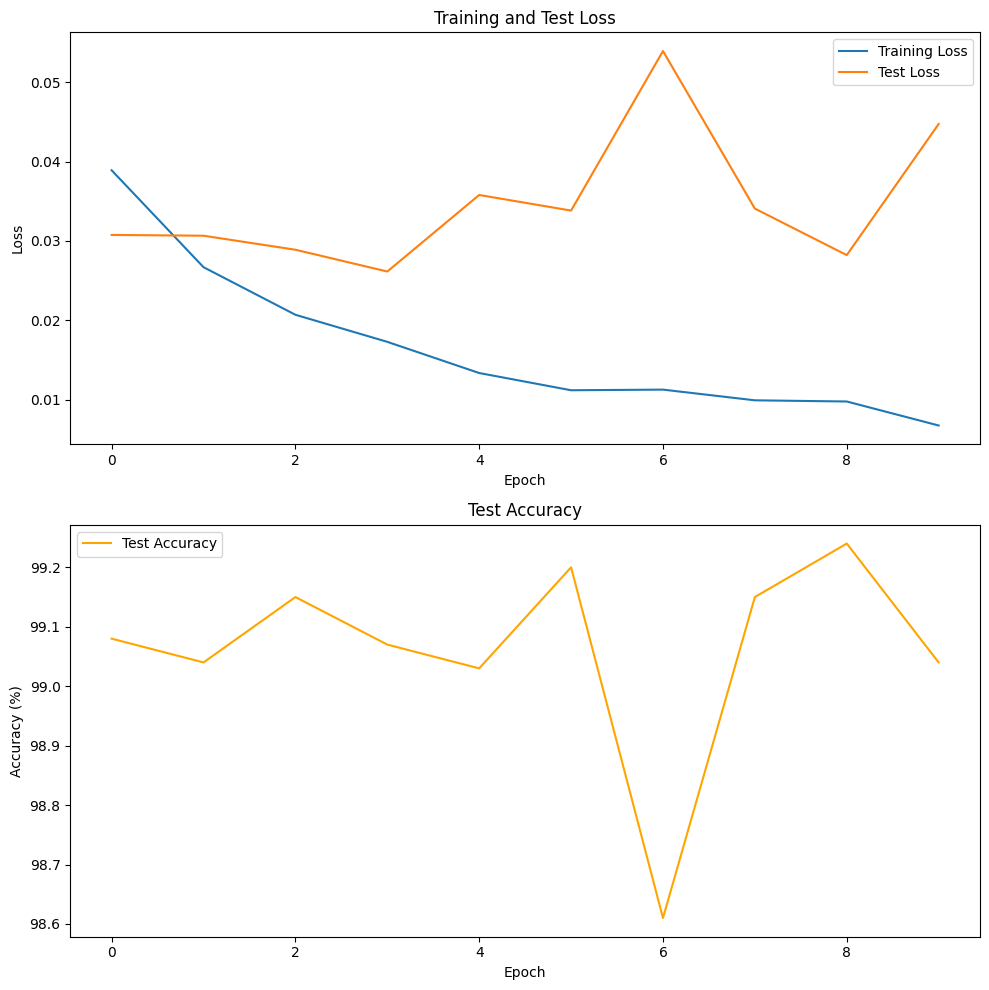

In [29]:
# 손실 및 정확도 시각화
fig, axs = plt.subplots(2,1,figsize=(10,10))
axs[0].plot(train_losses, label = 'Training Loss')
axs[0].plot(test_losses, label = 'Test Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].set_title('Training and Test Loss')

axs[1].plot(test_accuracies, label='Test Accuracy', color='orange')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].set_title('Test Accuracy')

plt.tight_layout()
plt.show()